## Loading intro stuff

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

In [4]:
from scipy.optimize import minimize
from pathlib import Path

In [5]:
bands = [4, 6, 7]
num_bands = len(bands)

In [7]:
# Initialize storage
results = {
    'Band': [],
    'POLF_Gaussian': [],
    'POLF_maxPOLI': [],
    'POLF_maxStokesI': []
}

for band in bands:
    # Use special case for Band 7
    var_name = f"band{band}_data_folder_path"
    path = Path(globals()[var_name]) / f"constants_BAND{band}.csv"


    df = pd.read_csv(path)

    results['Band'].append(band)
    results['POLF_Gaussian'].append(df.at[0, "POLF_Gaussian"] * 100)
    results['POLF_maxPOLI'].append(df.at[0, "POLF_maxPOLI"] * 100)
    results['POLF_maxStokesI'].append(df.at[0, "POLF_maxStokesI"] * 100)

# Convert to DataFrame
df_POLF = pd.DataFrame(results)

df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI
0,4,1.092126,1.581953,1.379366
1,6,0.914925,1.030456,0.972170
2,7,0.830213,1.084152,1.042140


In [8]:
lambda_bands_cm = mm_to_cm([lambda_mm[b] for b in bands])
band_colors = [alma_band_colors[b] for b in bands]

## test $\lambda$ and $a_{max}$

In [9]:
# Set up wavelength array
logwave_vals = np.linspace(0.1,4,10000)

lambda_dist_micron = 10**logwave_vals

lambda_dist_cm = micron_to_cm(lambda_dist_micron)

In [10]:
# a_max values for this plot
a_max_micron_fig1 = [1, 100]
a_max_cm_fig1 = micron_to_cm(a_max_micron_fig1)

In [11]:
N_grains = 200

In [12]:
f = 0.3

a_max_dist_micron = 1/f * np.logspace(np.log10(1e0), np.log10(1e4), N_grains)

a_max_dist_cm = micron_to_cm(a_max_dist_micron)

df = pd.DataFrame(a_max_dist_micron, columns=['a_max (micron)'])

print(rf'a_max ranges from:')
print(rf'{np.min(a_max_dist_micron)} to {np.max(a_max_dist_micron)} microns or')
print(rf'{np.min(a_max_dist_cm)} to {np.max(a_max_dist_cm)} cm')

a_max ranges from:
3.3333333333333335 to 33333.333333333336 microns or
0.0003333333333333334 to 3.333333333333334 cm


## run DSHARP model

In [13]:
oc, rho_g_cm3 = do.get_dsharp_mix(porosity = 1 - f)

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |
using Maxwell-Garnett mixing: first component should be host material (= matrix)
    matrix = Vacuum


In [14]:
res = do.get_opacities(a_max_cm_fig1, lambda_dist_cm, rho_g_cm3, oc)

Mie ... Done!


In [15]:
k_abs  = res['k_abs']
k_sca  = res['k_sca']
S1     = res['S1']
S2     = res['S2']
theta  = res['theta']

In [16]:
mass_grams_fig = calculate_grain_mass(a_max_dist_cm, rho_g_cm3, "cm")

In [17]:
res_scatter = do.get_opacities(a_max_dist_cm, lambda_bands_cm, rho_g_cm3, oc, n_angle=100)

zscat = do.calculate_mueller_matrix(lambda_bands_cm, mass_grams_fig, 
                                    res_scatter['S1'], res_scatter['S2'], 
                                    theta=res_scatter['theta'], 
                                    k_sca=res_scatter['k_sca'])['zscat']
theta = res_scatter['theta']


Mie ... Done!


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 88%: above error tolerance
  warnings.warn(


In [18]:
P, omega, P_times_omega = compute_P_and_omega_vs_amax(lambda_bands_cm, a_max_dist_cm, zscat, res_scatter, theta)

In [19]:
df['Pw B4'] = P_times_omega[:, 0]
df['Pw B6'] = P_times_omega[:, 1]
df['Pw B7'] = P_times_omega[:, 2]

## Figure 4

(-0.1, 1.5)

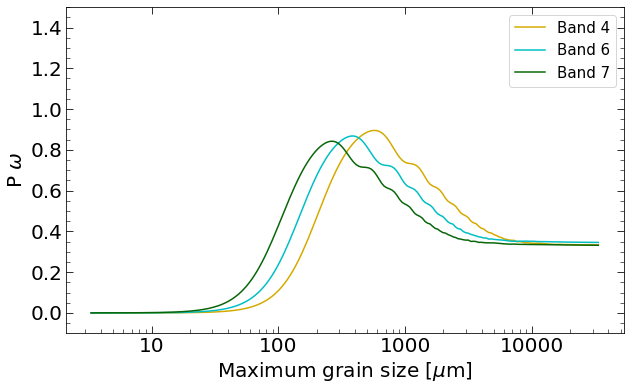

In [29]:
# mm

# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(10, 6))
#                [B4,  B6,   B7]

for i in range(num_bands):
    ax.plot(a_max_dist_micron,
            P_times_omega[:, i],
            color = band_colors[i],
            ls = '-',
            label = f'Band {bands[i]}')


# Add axis labels
ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

# ---------------------------------------------------------------------------------
ax.legend(fontsize = legend_text_fs)
  


ax.set_ylim(-0.1, 1.5)


## Find best $a_{max}$

The goal is to find the best grain size $a_{max}$ that makes the DSHARP model match the ovserved POLF as possible. 

For each $a_{max}$ we will find some scaling factor (sf) that will convert $P \omega$ to POLF

The function we want to minimize is the sum of squares:
sum of squares = $\sum_{i=1}^n(X_i - X)^2$, where

$X_i$ is the ith item

$X$ is the mean 

so, for this scenario $X_i$ is the model $P \omega$ times some scaling factor, and $X$ is the POLF value. 

We want to take the sum of squares for Band 4 + Band 6 + Band 7, and find the scaling factor that minimizes it.

In [21]:
def sum_of_sq(sf, model_Pw, obs_POLF):

    
    model_Pw_band4 = model_Pw[0]
    model_Pw_band6 = model_Pw[1]
    model_Pw_band7 = model_Pw[2]
    
    obs_POLF_band4 = obs_POLF[0]
    obs_POLF_band6 = obs_POLF[1]
    obs_POLF_band7 = obs_POLF[2]
    
    diff_sum_band4 = np.sum(sf*model_Pw_band4 - obs_POLF_band4)**2
    diff_sum_band6 = np.sum(sf*model_Pw_band6 - obs_POLF_band6)**2
    diff_sum_band7 = np.sum(sf*model_Pw_band7 - obs_POLF_band7)**2
    
    total = diff_sum_band4 + diff_sum_band6 + diff_sum_band7
    
    return total

We need to find the value the minimuzes the sum of squares for EACH of the N_grains values of $a_{max}$

In [22]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI
0,4,1.092126,1.581953,1.379366
1,6,0.914925,1.030456,0.972170
2,7,0.830213,1.084152,1.042140


In [23]:
POLF_columns = ['POLF_Gaussian', 'POLF_maxPOLI', 'POLF_maxStokesI']

# Create base DataFrame with a_max column
df = pd.DataFrame({'a_max micron': a_max_dist_micron})

for j in range(len(POLF_columns)):
    col_name = POLF_columns[j]
    print(f'We are now testing {col_name}:')

    POLF_test = df_POLF[col_name]

    scale_factors = []
    diff_array = []

    for i in range(N_grains):
        result = minimize(
            sum_of_sq,
            x0=0.01,
            args=(P_times_omega[i, :], POLF_test),
            bounds=[(0, None)]
        )

        sf_opt = result.x[0]
        err = result.fun

        scale_factors.append(sf_opt)
        diff_array.append(err)

    # Add columns to main df
    df[f'sf_{col_name}'] = scale_factors
    df[f'error_{col_name}'] = diff_array

We are now testing POLF_Gaussian:
We are now testing POLF_maxPOLI:
We are now testing POLF_maxStokesI:


In [ ]:
df

In [24]:
best_index_array = []
best_error_array = []
best_a_max_array = []
best_sf_array = []

for col_name in POLF_columns:
    print(f'We are now testing {col_name}:')

    best_index = np.argmin(df[f'error_{col_name}'])
    best_error = df[f'error_{col_name}'][best_index]
    best_a_max = a_max_dist_micron[best_index]
    best_sf = df[f'sf_{col_name}'][best_index]

    best_index_array.append(best_index)
    best_error_array.append(best_error)
    best_a_max_array.append(best_a_max)
    best_sf_array.append(best_sf)

    print(f"   The index with the lowest error from minimize is: {best_index}")
    print(f"   At this index, the corresponding error is       : {best_error:.3f}")
    print(f"   At this index, the corresponding a_max is       : {best_a_max:.1f} micron")
    print(f"   The scale factor at that a_max is               : {best_sf:.5f}")
    print(' ')

print(' ')
print(' ')

best_POLF_index = np.argmin(best_error_array)
best_POLF_column = POLF_columns[best_POLF_index]
best_POLF = df_POLF[best_POLF_column]
best_index = best_index_array[best_POLF_index]
best_error = best_error_array[best_POLF_index]
best_a_max = best_a_max_array[best_POLF_index]
best_sf = best_sf_array[best_POLF_index]


print(f'Out of the {len(df_POLF)} POLF options:')
print(f"   Lowest error occurs at POLF index of             : {best_POLF_index}")
print(f"   This POLF index corresponds to                   : {best_POLF_column}")   
print(f"   The POLFs at this best POLF column are           : {best_POLF[0]:.3f},  {best_POLF[1]:.3f},  {best_POLF[2]:.3f}")
print(f"   The index with the lowest error from minimize is : {best_index}")
print(f"   At this index, the corresponding error is        : {best_error:.3f}")
print(f"   At this index, the corresponding a_max is        : {best_a_max:.1f} micron")
print(f"   The scale factor at that a_max is                : {best_sf:.5f}")


We are now testing POLF_Gaussian:
   The index with the lowest error from minimize is: 112
   At this index, the corresponding error is       : 0.000
   At this index, the corresponding a_max is       : 594.5 micron
   The scale factor at that a_max is               : 1.22399
 
We are now testing POLF_maxPOLI:
   The index with the lowest error from minimize is: 143
   At this index, the corresponding error is       : 0.038
   At this index, the corresponding a_max is       : 2496.0 micron
   The scale factor at that a_max is               : 2.82730
 
We are now testing POLF_maxStokesI:
   The index with the lowest error from minimize is: 147
   At this index, the corresponding error is       : 0.020
   At this index, the corresponding a_max is       : 3003.7 micron
   The scale factor at that a_max is               : 2.77278
 
 
 
Out of the 3 POLF options:
   Lowest error occurs at POLF index of             : 0
   This POLF index corresponds to                   : POLF_Gaussian
   Th

(-0.1, 1.5)

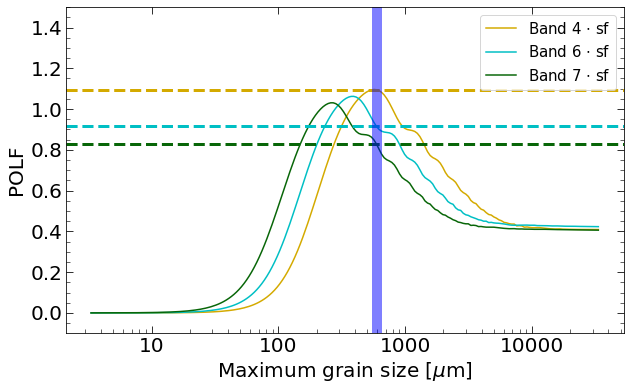

In [25]:
# mm

# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(10, 6))
#                [B4,  B6,   B7]
P_scale_factor = [1.15, 1.68, 1.2]

for i in range(num_bands):
    ax.plot(a_max_dist_micron,
            P_times_omega[:, i] * best_sf,
            color = band_colors[i],
            ls = '-',
            label = f'Band {bands[i]} $\cdot$ sf')


# Add axis labels
ax.set_xlabel('Maximum grain size [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('POLF', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

# ---------------------------------------------------------------------------------
ax.legend(fontsize = legend_text_fs)
  
    
# Add horizontal lines of POLF_avg at each band if my own data
for i in range(num_bands):
    ax.axhline(best_POLF[i], color = band_colors[i], ls = '--', lw = 3)

ax.axvline(best_a_max, color = 'blue', ls = '-', lw = 10, alpha = 0.5)

ax.set_ylim(-0.1, 1.5)
